<a href="https://colab.research.google.com/github/BrindanYasodaran/CVIS-oxford/blob/main/practical2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision MM 2025 - Practical 2 (v1.0)

## Instructions

1. Start Google Colab: https://colab.research.google.com. A modal dialog should have appeared to open a new notebook. If not, go to "File>Open notebook".
2. From the open notebook dialog, select the GitHub "tab" and enter this URL: https://github.com/chrirupp/cv_course
3. The notebook(s) should appear (*.ipynb). Select the one for the current practical.
4. To run a notebook on Colab you will typically need some data files (e.g., images). As Colab only loads the notebook itself, these other files need to be downloaded separately. The following cell is a `%%sh` block that downloads the required files. You can inspect the downloaded files by clicking on the "Files" tab on the left.

## Practicalities

The signing-off happens in the last half hour of each session or at the beginning of the following one.
As usual, when checking your work the demonstrator will want to see a working version of the program in action, as well as appropriate comments of your code. Try to make your report as concise as possible, perhaps in the form of appropriate comments to your code.

Since this is a new practical task, any errors, ambiguities or suggestions for improvement should be flagged as soon as possible.

If you are not familiar with the way practicals run, there are department-wide [rules](https://www.cs.ox.ac.uk/teaching/courses/2023-2024/practicals/). There you will find how the compulsory part, the optional tasks, and your report will factor into your mark.

## Advice

* You will need to look at the code for the lectures. There you will find many related computations that you can reuse and adapt to solve the practicals.
* The compulsory part of this practical is designed to give you additional understanding of the concepts taught in the lectures. It should be achievable in one session.

Here we import some libraries that we will need to process images, do maths, and to visualise results.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torch
from tqdm import tqdm
from torchvision import datasets, transforms
%matplotlib inline

The usual set of helper functions:

In [2]:
%%sh
# Download the data - you need to do this only once
wget --no-verbose --output-document=image_dog.jpg https://github.com/chrirupp/cv_course/raw/main/data/image_dog.jpg

2025-11-01 15:49:15 URL:https://raw.githubusercontent.com/chrirupp/cv_course/main/data/image_dog.jpg [138693/138693] -> "image_dog.jpg" [1]


In [3]:
class Visualizer():
    def __init__(self, num_rows=1, num_cols=1, figsize=(5,5), axis_off=True, title='', tight=False, cm=None):
        fig, self.axs = plt.subplots(num_rows, num_cols, figsize=figsize, squeeze=False)
        # remove ticks
        if axis_off:
          plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[])
        # set colormap
        if cm is not None:
            plt.set_cmap(cm)
        # set supertitle
        fig.suptitle(title)
        if tight:
            fig.subplots_adjust(top=0.88)

    def add_image_subplot(self, i, j, image, normalize=False, title_str=''):
        if normalize:
            image = self.normalize_image(image)
        if len(image.shape) == 3:
            #BGR -> RGB
            image = image[:, :, ::-1]
        self.axs[i, j].imshow(image)
        self.axs[i, j].set_title(title_str)

    def add_stem_subplot(self, i, j, x, y, title_str=''):
        self.axs[i, j].stem(x, y)
        self.axs[i, j].set_title(title_str)

    def add_subplot(self, i, j, data, title_str=''):
        self.axs[i, j].plot(data)
        self.axs[i, j].set_title(title_str)

    def add_bar_subplot(self, i, j, x, y, title_str=''):
        self.axs[i, j].bar(x, y)
        self.axs[i, j].set_title(title_str)

    @staticmethod
    def normalize_image(image):
        img = np.float64(image) - np.min(image)
        img /= np.max(img)
        return img

## Problem 2.1 - Image Classification

Let us train a linear classifier on the CIFAR10 dataset.
First, we will load the dataset and show some sample images. The convention in pytorch is to store images in a tensor of shape $C\times H \times W$, where $C=3$ is the number of channels and $H$ and $W$ are the height and width of the image. For training, we typically load mini-batches of size $N$, which adds another dimension $N \times C \times H \times W$ to our data. The image visualiser expects data in the format $H \times W \times C$ so you will find some shuffling of dimension in the code below. Additionally, OpenCV prefers processing images in BGR format, while pytorch uses RGB so we also need to reverse the order of the $C$ dimension.

100%|██████████| 170M/170M [00:03<00:00, 43.2MB/s]


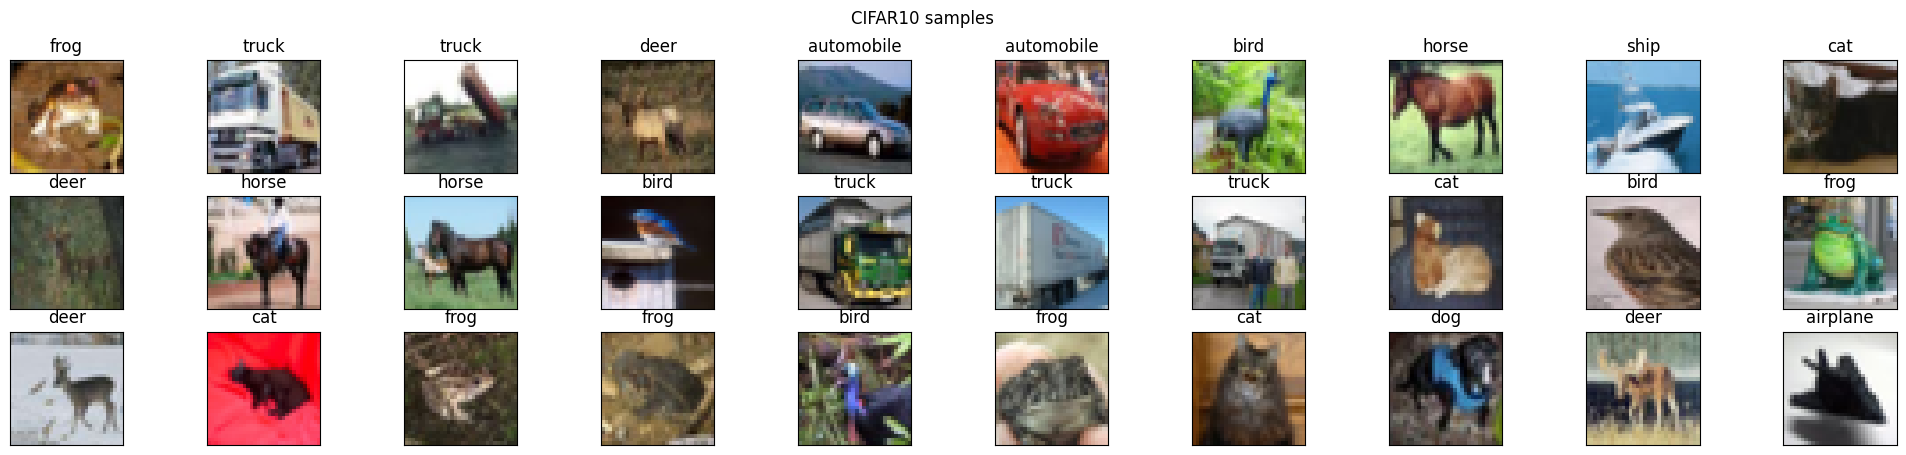

In [4]:
# get cifar10 dataset
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.CIFAR10('../data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('../data', train=False, download=True, transform=transform)


# samples from cifar10 dataset
vis = Visualizer(3, 10, figsize=(25,5), title='CIFAR10 samples')
for i in range(30):
    image = train_dataset[i][0].permute(1, 2, 0).numpy()[:,:,::-1]
    vis.add_image_subplot(i // 10, i % 10, image, title_str=train_dataset.classes[train_dataset[i][1]])


While we can "train" a linear classifier by solving a linear system analytically, we will now do it with gradient descent to familiarise ourselves with the concepts of training. Training typically happens in epochs, where one epoch is a full loop over the training set. Familiarise yourself with the training code below. Answer the following questions:

Questions
* What is the purpose of `optimizer.zero_grad()`?
* What is `citerion`?
* How do we determine which class the model predicts?
* How many parameters does our model have?
* What accuracy would we expect for a model that is randomly initialised?

# Answer
- Parameter objects of the model store gradients. When computing the gradient of the loss using the next mini batch, we need to zero out the gradients computed using the previous mini batch.
- Criterion is the loss function used to compare how close our predictions are to the targets. Here, we use cross entropy which is the negative log probability that the model predicted for the target class.
- The model predicts the class for which it gave the largest logit output for
- 3x32x32x10 weights, 10 biases, giving 30,730 weights (not including hyperparams)
- About 10% top-1 accuracy for the CIFAR10 dataset

In [5]:
# create dataloaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

def evaluate(model, test_loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    accuracy = 100. * correct / len(test_loader.dataset)
    return accuracy

def train(model, train_loader, test_loader, criterion, optimizer, num_epochs=10):
    train_losses = []
    test_accuracies = []
    for epoch in range(num_epochs):
        model.train()
        for data, target in tqdm(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        test_acc = evaluate(model, test_loader)
        test_accuracies.append(test_acc)
        print(f'Epoch {epoch+1}/{num_epochs}, Test accuracy: {test_acc:.2f}%')

    return train_losses, test_accuracies

class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = torch.nn.Linear(3*32*32, 10)

    def forward(self, x):
        x = x.view(-1, 3*32*32)
        x = self.fc(x)
        return x

model = LinearModel()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_losses, test_accuracies = train(model, train_loader, test_loader, criterion, optimizer, num_epochs=5)


100%|██████████| 391/391 [00:06<00:00, 61.52it/s]


Epoch 1/5, Test accuracy: 33.42%


100%|██████████| 391/391 [00:07<00:00, 55.35it/s]


Epoch 2/5, Test accuracy: 36.90%


100%|██████████| 391/391 [00:06<00:00, 59.96it/s]


Epoch 3/5, Test accuracy: 34.23%


100%|██████████| 391/391 [00:06<00:00, 56.76it/s]


Epoch 4/5, Test accuracy: 36.96%


100%|██████████| 391/391 [00:06<00:00, 56.30it/s]


Epoch 5/5, Test accuracy: 38.11%


Now that the model is trained, visualise the weights of the linear layer. There are $3\cdot 32 \cdot 32$ weights for each class which you can visualise simply as an image. What do you see? Why does it look like that?

# Answer
- We can see that the weights of a class vaguely correspond to an outline of that class
- This is most noticable for the horse image
- This is because the model is linear on raw pixels, so each class’s score is just a template match.
- Training pushes weights for class k to be positive where pixels tend to be “on” for class.

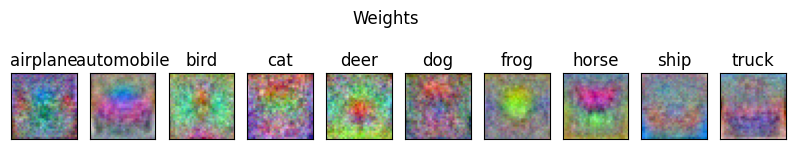

In [14]:
vis = Visualizer(1, 10, figsize=(10,2), title='Weights')

params = []
for param in model.parameters():
  param = param.detach().numpy()
  params.append(param)

all_weights = params[0]

for i in range(10):
    # pick class-i weights -> (3072,)
    w = all_weights[i]

    # reshape to (C,H,W) then to (H,W,C)
    w = w.reshape(3, 32, 32).transpose(1, 2, 0)   # (32,32,3)

    #  Visualizer/OpenCV expects BGR
    w = w[:, :, ::-1]

    vis.add_image_subplot(0, i, w, title_str=train_dataset.classes[i], normalize=True)

We will now train a small CNN. It consists of
* Convolution: size 3x3, number of channels 3 (RGB), number of filters: 16, padding: 1 on all sides
* ReLU
* MaxPooling: size 2x2, stride: 2
* Fully Connected layer: 4096 x 10

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

class MiniCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.fc = torch.nn.Linear(4096, 10)

    def forward(self, x):
        x = torch.nn.functional.relu(self.conv1(x))
        x = torch.nn.functional.max_pool2d(x, kernel_size=2, stride=2)
        x = x.view(-1, 4096)
        x = self.fc(x)
        return x

model = MiniCNN()
# TODO: train the model

# train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
# test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MiniCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == targets).sum().item()
        total += images.size(0)

    return running_loss / total, running_correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        logits = model(images)
        loss = criterion(logits, targets)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == targets).sum().item()
        total += images.size(0)

    return running_loss / total, running_correct / total

epochs = 10
best_acc = 0.0
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "mini_cnn_best.pt")
    print(f"Epoch {epoch:02d} | "
          f"train loss {train_loss:.4f}, acc {train_acc*100:.2f}% | "
          f"test loss {test_loss:.4f}, acc {test_acc*100:.2f}%")

print(f"Best test accuracy: {best_acc*100:.2f}% (weights saved to mini_cnn_best.pt)")

Epoch 01 | train loss 1.6989, acc 40.79% | test loss 1.5186, acc 47.25%
Epoch 02 | train loss 1.4229, acc 50.87% | test loss 1.3721, acc 51.81%
Epoch 03 | train loss 1.3177, acc 54.58% | test loss 1.3033, acc 54.16%
Epoch 04 | train loss 1.2579, acc 56.59% | test loss 1.2801, acc 55.20%
Epoch 05 | train loss 1.2170, acc 58.01% | test loss 1.2349, acc 56.59%
Epoch 06 | train loss 1.1779, acc 59.63% | test loss 1.2391, acc 56.86%
Epoch 07 | train loss 1.1504, acc 60.47% | test loss 1.1931, acc 58.29%
Epoch 08 | train loss 1.1238, acc 61.52% | test loss 1.1803, acc 59.49%
Epoch 09 | train loss 1.1013, acc 62.13% | test loss 1.1504, acc 60.06%
Epoch 10 | train loss 1.0820, acc 62.86% | test loss 1.1630, acc 59.38%
Best test accuracy: 60.06% (weights saved to mini_cnn_best.pt)


This model should achieve around 57% accuracy on the test set (with the default settings for batch size, learning rate, and number of epochs).

Answer the following questions:
* Why do we need to define the convolution and FC layer in the constructor (`__init__()`) of the model, but ReLU and max_pool are simply used in the forward pass?
* How do we know that the fully connected layer needs to be of size 4096 x 10?

Then, expand the model with a second set of convolution (3x3, 32 filters, padding 1), ReLU, max_pool (2x2, stride 2). You will need to also adjust the size of the FC layer accordingly. Confirm that this improves the accuracy.

# Answer
- conv layers and FC layers have parameter values that need tracking. ReLU and max pool do not - we can just call the functional versions of these in the forward pass.
- the Conv2d with 16 out channels, 3x3 kernel, stride 1, padding 1 which takes as input (C, H, W) = (3, 32, 32), has output tensors of size (16, 32, 32). The max pool with 2x2 kernel and stride 2 reduces size by a factor of 2, giving output of size (16,16,16). This is flattened before being passed to the fc layer, and so the fc layer needs have input size of 16x16x16=4096. And it also has to output logits for 10 classes.


In [17]:
import torch.nn.functional as F

class MiniCNN2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.fc    = nn.Linear(32 * 8 * 8, 10)  # 32×8×8 = 2048

    def forward(self, x):
        x = F.relu(self.conv1(x))                       # (B,16,32,32)
        x = F.max_pool2d(x, kernel_size=2, stride=2)    # (B,16,16,16)
        x = F.relu(self.conv2(x))                       # (B,32,16,16)
        x = F.max_pool2d(x, kernel_size=2, stride=2)    # (B,32,8,8)
        x = x.view(x.size(0), -1)                       # (B,2048)
        x = self.fc(x)                                  # (B,10)
        return x

model = MiniCNN2().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == targets).sum().item()
        total += images.size(0)

    return running_loss / total, running_correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        logits = model(images)
        loss = criterion(logits, targets)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == targets).sum().item()
        total += images.size(0)

    return running_loss / total, running_correct / total

epochs = 10
best_acc = 0.0
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "mini_cnn2_best.pt")
    print(f"Epoch {epoch:02d} | "
          f"train loss {train_loss:.4f}, acc {train_acc*100:.2f}% | "
          f"test loss {test_loss:.4f}, acc {test_acc*100:.2f}%")

print(f"Best test accuracy: {best_acc*100:.2f}% (weights saved to mini_cnn2_best.pt)")

Epoch 01 | train loss 1.6763, acc 40.77% | test loss 1.4174, acc 50.35%
Epoch 02 | train loss 1.3600, acc 52.31% | test loss 1.3483, acc 53.11%
Epoch 03 | train loss 1.2388, acc 56.83% | test loss 1.2094, acc 57.54%
Epoch 04 | train loss 1.1651, acc 59.55% | test loss 1.1538, acc 59.85%
Epoch 05 | train loss 1.1066, acc 61.57% | test loss 1.1278, acc 61.02%
Epoch 06 | train loss 1.0629, acc 63.31% | test loss 1.0749, acc 62.44%
Epoch 07 | train loss 1.0294, acc 64.33% | test loss 1.0696, acc 62.72%
Epoch 08 | train loss 0.9970, acc 65.43% | test loss 1.0299, acc 64.26%
Epoch 09 | train loss 0.9723, acc 66.38% | test loss 1.0144, acc 64.72%
Epoch 10 | train loss 0.9470, acc 67.34% | test loss 0.9831, acc 65.74%
Best test accuracy: 65.74% (weights saved to mini_cnn2_best.pt)


### Optional Task - Be a hero
You have now several options that might improve the performance:
* Change the architecture further.
* Train longer.
* Change other hyper parameters: batch size, learning rate, kernel sizes, number of filters, activation functions, etc.
* Data augmentations such as left-right flipping (see `transform` in the beginning).

Try to find a combination that gets better accuracy than `MiniCNN2` (at least 63%). Do not change the test set! (State-of-the-art models get around 95% ;) )
Hint: if you are considering to tinker with this for a while: switch to hardware acceleration (GPU) - Edit->Notebook settings. Then change the code to move the model and tensors to the GPU `.to("cuda")` before starting to train. You will need to move each batch to the device too. Move predictions back to the CPU `.cpu()` so that they do not accumulate memory.

# Answer
- We use ResNet18 model
- The ImageNet stem in ResNet-18 is a 7×7, stride-2 conv followed by a 3×3, stride-2 max-pool. On 32×32 inputs that would downsample too heavily
- This is swapped for 3×3, stride-1, padding-1 conx, with no max pooling

In [18]:
from torchvision import models

class CIFARResNet(nn.Module):
    def __init__(self, num_classes=10, pretrained=True):
        super().__init__()
        # Start from ImageNet ResNet-18
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)

        # CIFAR-10 friendly stem: 3x3 conv, stride=1, padding=1; remove initial maxpool
        self.backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.backbone.maxpool = nn.Identity()

        # Replace classifier for 10 classes
        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_feats, num_classes)

    def forward(self, x):
        return self.backbone(x)

model = CIFARResNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == targets).sum().item()
        total += images.size(0)

    return running_loss / total, running_correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        logits = model(images)
        loss = criterion(logits, targets)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == targets).sum().item()
        total += images.size(0)

    return running_loss / total, running_correct / total

epochs = 30
best_acc = 0.0
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "CIFARResNet_best.pt")
    print(f"Epoch {epoch:02d} | "
          f"train loss {train_loss:.4f}, acc {train_acc*100:.2f}% | "
          f"test loss {test_loss:.4f}, acc {test_acc*100:.2f}%")

print(f"Best test accuracy: {best_acc*100:.2f}% (weights saved to CIFARResNet_best.pt)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


Epoch 01 | train loss 2.4246, acc 21.98% | test loss 1.8378, acc 33.55%
Epoch 02 | train loss 1.6203, acc 40.34% | test loss 1.4719, acc 45.60%
Epoch 03 | train loss 1.3443, acc 51.08% | test loss 1.2172, acc 55.98%
Epoch 04 | train loss 1.1268, acc 59.72% | test loss 1.1334, acc 58.94%
Epoch 05 | train loss 0.9409, acc 66.67% | test loss 1.0483, acc 63.93%
Epoch 06 | train loss 0.8124, acc 71.45% | test loss 1.0212, acc 65.36%
Epoch 07 | train loss 0.7127, acc 74.73% | test loss 0.8216, acc 71.74%
Epoch 08 | train loss 0.6215, acc 78.27% | test loss 0.7942, acc 73.16%


KeyboardInterrupt: 

## Problem 2.2 - Occlusion Method

The code for the lecture implements the occlusion method for CNNs, by blocking out (i.e. setting to 0) parts of the image and measuring the change in response for the target class for every location, and converting it into a heatmap.
We will now do the same for a transformer architecture. However, since the transformer already divides the image into patches, we can directly block out tokens instead of modifying the image.

Downloading: "https://github.com/pytorch/vision/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 67.8MB/s]


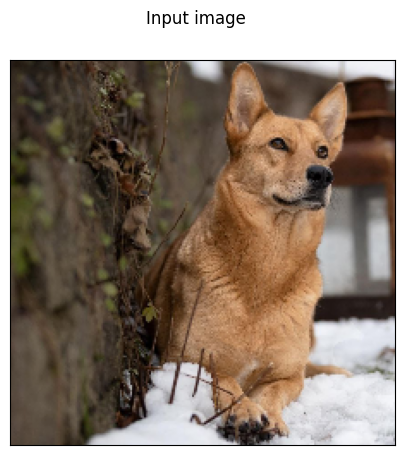

In [19]:
model = torch.hub.load('pytorch/vision', 'vit_b_16', weights=torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1)
class_names = torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1.meta["categories"]

# load image
image = cv2.imread('image_dog.jpg')

# preprocess image
image = image[:, :image.shape[0]]
image = cv2.resize(image, (224, 224))
vis = Visualizer(num_rows=1, num_cols=1, figsize=(5,5), axis_off=True, title='Input image')
vis.add_image_subplot(0, 0, image)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = image / 255.0
image = image - np.array([0.485, 0.456, 0.406])
image = image / np.array([0.229, 0.224, 0.225])
image = image.transpose(2, 0, 1)
image = np.expand_dims(image, axis=0)
image = torch.from_numpy(image).float()

Models trained on the ImageNet dataset are trained using normalised images (subtract mean, divide by variance) this is reflected in the image pre-processing code above.

Below you are given a function `predict`.

Explain:
* the role of `batch_class_token`
* `encoder.pos_embedding`
* the reason for `x[:, 0]`


# Answer
- it is a learnable vector prepended to every patch sequence. It acts as a global “summary” token that attends to all patches. it holds an image-level representation for classification.
- Learnable positional encodings added to the token embeddings so the transformer knows each token’s position. WIthout them attention is position equivariant
- Selects the class token from the full sequence of patches

In [20]:
def predict(model, image):
    x = model._process_input(image) #(batch size, number of patches, embedding dimension)
    n = x.shape[0]
    batch_class_token = model.class_token.expand(n, -1, -1) # repeat class token n times (n, 1, D)
    x = torch.cat([batch_class_token, x], dim=1)

    input = x + model.encoder.pos_embedding
    input = model.encoder.layers(input)
    x = model.encoder.ln(input)
    x = x[:, 0] # take class token only: (n, D)
    return model.heads(x).detach().cpu().numpy() #logits: (n, C)

# predict
output = predict(model, image)
pred = class_names[output.argmax()]
print(f'Predicted class: {pred}')

Predicted class: dingo


Implement the occlusion method by individually "occluding" image token from the input to the encoder and measuring the change in the target class. Be careful: the class-token is the first token in the input sequence. Visualise the heatmap.

Class: dingo


100%|██████████| 196/196 [01:16<00:00,  2.56it/s]


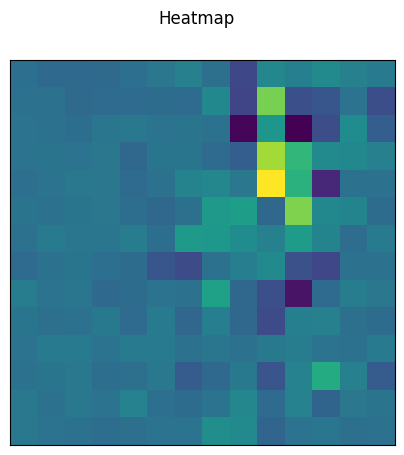

In [22]:
def predict_drop_token(model, image, token_idx):
    with torch.no_grad():
        # Patch embeddings: (1, L, D)
        x = model._process_input(image)
        n, L, D = x.shape

        # Class token: (1, 1, D)
        batch_class_token = model.class_token.expand(n, -1, -1)

        # Concatenate class token + patches: (1, 1+L, D)
        x = torch.cat([batch_class_token, x], dim=1)

        # Add positional embeddings  (1, 1+L, D)
        inp = x + model.encoder.pos_embedding

        seq_idx = 1 + token_idx
        inp = inp.clone()
        inp[:, seq_idx, :] = 0.0

        # Encode
        h = model.encoder.layers(inp)     # (1, 1+L, D)
        h = model.encoder.ln(h)           # (1, 1+L, D)

        # Take class token (index 0)
        cls = h[:, 0]
        logits = model.heads(cls)         # (1, C)
        return logits.detach().cpu().numpy()

# get prediction
with torch.no_grad():
    original_prediction = predict(model, image)

top_class = original_prediction.argmax()
print(f'Class: {class_names[top_class]}')

with torch.no_grad():
    x = model._process_input(image)   # (1, L, D)
    L = x.shape[1]

# Hp = int(np.sqrt(L))
# Wp = L // Hp
H, W = image.shape[-2:]
P = model.conv_proj.kernel_size[0]   # torchvision ViT stem; stride == patch size
Hp, Wp = H // P, W // P

heatmap = np.zeros((Hp, Wp))
for i in tqdm(range(heatmap.size)):
    response = predict_drop_token(model, image, i)
    # heatmap[?, ?] = 0  # TODO: calculate the heatmap
    heatmap.flat[i] = original_prediction[0, top_class] - response[0, top_class]

# plot heatmap
vis = Visualizer(num_rows=1, num_cols=1, figsize=(5,5), axis_off=True, title='Heatmap')
vis.add_image_subplot(0, 0, heatmap)


## Optional Task - Visualise Everything
Upload some images and show predictions and heatmaps. Are their clear failure modes? What happens if you visualise a class that is not in the image?

## Problem 2.3 - Adversarial Examples

Adversarial examples are inputs to the network that look like normal images to humans, but cause the network to predict completely wrong classes with very high confidence. The are called _adversarial_ since they are specifically constructed to fool the model while being imperceptible to humans.

A straightforward way to construct adversarial examples is a process very similar to the Input Reconstruction visualisation technique. However, instead of starting the optimisation from random noise, we start from the image that we want to modify. We then make small gradient steps in the image that maximise our target adversarial class. Here, we do not need any regularisers since we are looking for a solution very close to the original image.

Take the input reconstruction code from the lecture notebook on visualisation as an example on how to setup gradient descent on pixels, given a network and target class.
* You will not need any regularisation techniques.
* you also do not need to normalise the gradient.
* start from image_dog instead of random noise.
* choose a target class (e.g. 637 "mailbox")
* optimise and show your adversarial example.
* pass your adversarial example through the model and show that it predicts the target class.

Hint: you will need to normalise the image (like in the code above). When visualising the result, you need to invert this process.

In [ ]:
# load image
image = cv2.imread('image_dog.jpg')

# preprocess image
image = image[:, :image.shape[0]]
image = cv2.resize(image, (224, 224))
vis = Visualizer(num_rows=1, num_cols=1, figsize=(5,5), axis_off=True, title='Input image')
vis.add_image_subplot(0, 0, image)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = image / 255.0
image = image - np.array([0.485, 0.456, 0.406])
image = image / np.array([0.229, 0.224, 0.225])
image = image.transpose(2, 0, 1)
image = np.expand_dims(image, axis=0)
image = torch.from_numpy(image).float()

def de_normalise_image(x):
    # TODO: denormalise image (test it by using it on the normalised image and plot it)
    return x

model = torch.hub.load('pytorch/vision', 'resnet50', weights=torchvision.models.resnet.ResNet50_Weights.DEFAULT)
class_names = torchvision.models.resnet.ResNet18_Weights.DEFAULT.meta["categories"]

# pass image through model
output = model(image)
pred = output.argmax()
print(f'Predicted class: {class_names[pred]}')

top_class = 637 # This is the class for 'mailbox'
num_iterations = 50
input = 0  # TODO: initialise with image
input = torch.nn.Parameter(input, requires_grad=True)
optimizer = torch.optim.Adam([input], lr=0.1)

for i in tqdm(range(num_iterations)):
    prediction = model(input)
    loss = 0  # TODO: find a loss function that maximises the class score
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

vis = Visualizer(num_rows=1, num_cols=1, figsize=(5,5), axis_off=True, title=f'Input maximisation class {class_names[top_class]}')
vis.add_image_subplot(0, 0, de_normalise_image(image))

# pass image through model
output = model(input)
# get class index
pred = output.argmax()
print(f'Predicted class of adversarial example: {class_names[pred]}')

Visualise the difference image between the original and the adversarial example.
* Do the same for different classes.
* Modify the code so that the loop ends as soon as the target class is higher than all others. Are some classes "easier" than others?

## Optional Tasks
* Save and load an adversarial example to and from a jpg file. Does it still work? Why? How could you make it more robust?
* Universal perturbations: another curious finding is that there are universal perturbations. A UP is a noise pattern $\epsilon$ that, if added to _any_ image, causes a misclassification as the target class. Try to find a universal perturbation for one of your CIFAR10 CNNs from the first problem of this sheet. You can do this by running the learning of the perturbation over batches of the training set. For each image in the batch, you will need to add your universal perturbation. The only thing that is learned in this training loop is the pattern (the model stays fixed). Learn your universal perturbation on the training set and show some examples on the test set. How do they compare to adversarial examples?
